# Sammenligning af to LLM'er: Haiko vs. Opus

Statistisk evaluering af to sprogmodeller på et eksamenssæt, hvor hvert spørgsmål er
bedømt af 5 evaluatorer. Metoderne (Jeffrey's interval og McNemars test) følger
`exercise7` fra kurset:

1. **Opsætning** – indlæs og ryd op i data (gøres én gang).
2. **Deskriptiv analyse** – accuracy pr. spørgsmålstype + agreement-matrix.
3. **Del 1 – Jeffrey's interval** – konfidensinterval for hver enkelt model.
4. **Del 2 – McNemars test** – statistisk sammenligning af de to modeller.


## 1. Opsætning

Her samles alle imports, og datafilen indlæses og renses **én gang**. Alle senere
celler genbruger `df` herfra i stedet for at indlæse filen forfra.


In [8]:
import numpy as np
import pandas as pd
import scipy.stats as st
from scipy.stats import beta
import matplotlib.pyplot as plt
import seaborn as sns

# Sti til datafilen (semikolon-separeret, BOM-tegn, og tomme "Unnamed"-kolonner til sidst)
path = "Dataset.csv"

df = pd.read_csv(path, sep=";", encoding="utf-8-sig")

# Ryd op:
df = df.loc[:, ~df.columns.str.startswith("Unnamed")]   # fjern tomme kolonner
df.columns = df.columns.str.strip()                       # trim kolonnenavne
df["Q_Type"] = df["Q_Type"].str.strip().replace({"Knowlegde": "Knowledge"})  # ret stavefejl

df

,Examset,Question,Q_Type,Haiko True,Haiko False,Opus True,Opus False
0,Spring 2025,1,Visual,5,0,5,0
1,Spring 2025,2,Visual,0,5,5,0
2,Spring 2025,3,Computational,0,5,5,0
3,Spring 2025,4,Visual,4,1,4,1
4,Spring 2025,5,Knowledge,0,5,5,0
5,Spring 2025,6,Computational,1,4,5,0
6,Spring 2025,7,Computational,0,5,5,0
7,Spring 2025,8,Computational,0,5,5,0
8,Spring 2025,9,Visual,0,5,5,0
9,Spring 2025,10,Computational,0,5,1,4


Vi udvider data til **langt format** med 270 rækker (5 evaluatorer × 54 spørgsmål).
Hver evaluering bliver et binært udfald: `1` = korrekt, `0` = forkert. Disse variabler
(`y_true`, `yhatA`, `yhatB`) bruges i både Jeffrey's interval og McNemars test.


In [9]:
# Udvid til 270 rækker (5 evaluatorer × 54 spørgsmål)
# Hver række bliver til 5 binære udfald (1 = korrekt, 0 = forkert) pr. model.
expanded = []
for _, row in df.iterrows():
    for i in range(5):
        haiko = 1 if i < row['Haiko True'] else 0
        opus  = 1 if i < row['Opus True']  else 0
        expanded.append({'Haiko': haiko, 'Opus': opus})

df_exp = pd.DataFrame(expanded)
y_true = np.ones(len(df_exp), dtype=int)   # ground truth: alle bør være korrekte
yhatA  = df_exp['Haiko'].values
yhatB  = df_exp['Opus'].values
len(df_exp)

270

## 2. Deskriptiv analyse

### 2.1 Accuracy pr. spørgsmålstype
Samlet accuracy og opdelt på spørgsmålstype (Visual, Computational, Knowledge).


ACCURACY BY QUESTION TYPE

Overall:
  Haiko: 44.1%
  Opus:  85.6%
  Diff:  +41.5%

Computational:
  Haiko: 22.4%
  Opus:  95.3%
  Diff:  +72.9%

Knowledge:
  Haiko: 60.0%
  Opus:  92.0%
  Diff:  +32.0%

Visual:
  Haiko: 51.9%
  Opus:  77.0%
  Diff:  +25.2%



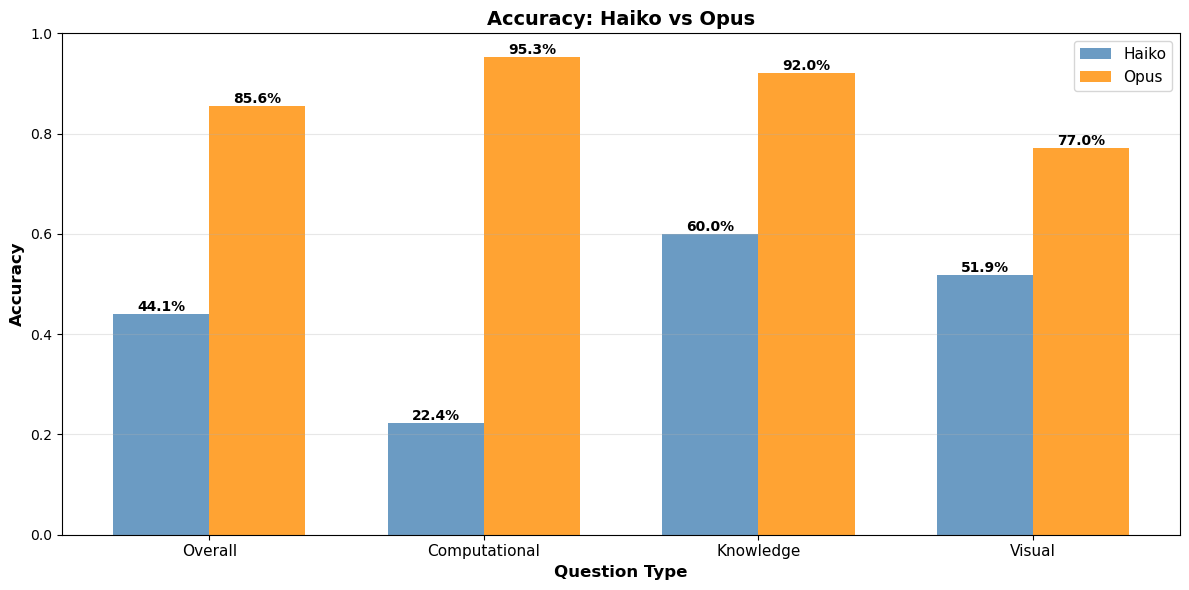

In [10]:
# Samlet accuracy
total_evaluations = len(df) * 5
haiko_total = df['Haiko True'].sum() / total_evaluations
opus_total = df['Opus True'].sum() / total_evaluations

# Accuracy pr. spørgsmålstype
q_types = df['Q_Type'].unique()
results = {'Overall': [haiko_total, opus_total]}

for qtype in sorted(q_types):
    subset = df[df['Q_Type'] == qtype]
    haiko_acc = subset['Haiko True'].sum() / (len(subset) * 5)
    opus_acc = subset['Opus True'].sum() / (len(subset) * 5)
    results[qtype] = [haiko_acc, opus_acc]

print("=" * 60)
print("ACCURACY BY QUESTION TYPE")
print("=" * 60)

for qtype, accs in results.items():
    print(f"\n{qtype}:")
    print(f"  Haiko: {accs[0]:.1%}")
    print(f"  Opus:  {accs[1]:.1%}")
    print(f"  Diff:  {accs[1] - accs[0]:+.1%}")

print("\n" + "=" * 60)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(results))
width = 0.35
haiko_vals = [results[k][0] for k in results.keys()]
opus_vals = [results[k][1] for k in results.keys()]
bars1 = ax.bar(x - width/2, haiko_vals, width, label='Haiko', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, opus_vals, width, label='Opus', color='darkorange', alpha=0.8)
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_xlabel('Question Type', fontsize=12, fontweight='bold')
ax.set_title('Accuracy: Haiko vs Opus', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results.keys(), fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3, axis='y')
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.2 Agreement-matrix
En 2×2-matrix der viser hvor ofte de to modeller er enige/uenige om de samme spørgsmål.


/var/folders/x7/4vlz4tnd7nv569zqczv819wr0000gn/T/ipykernel_10959/4005889761.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  n11 = (df[df['Haiko_Correct'] == 1][df['Opus_Correct'] == 1]['Haiko True'].sum())


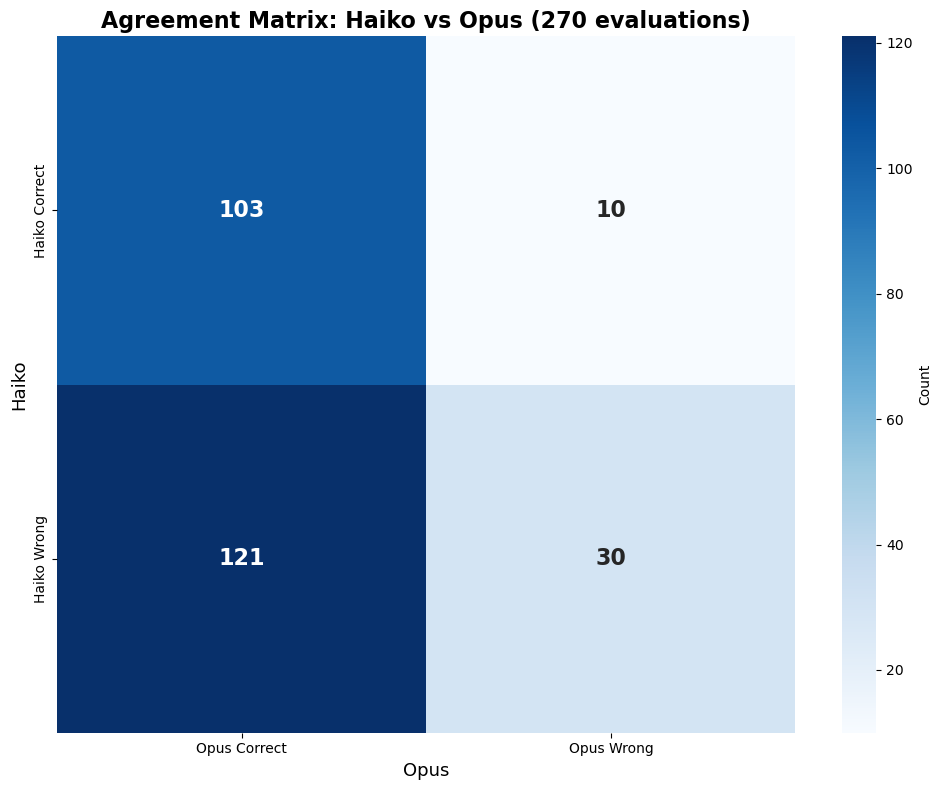

Both Correct (n11):           103
Haiko ✓, Opus ✗ (n12):        10
Haiko ✗, Opus ✓ (n21):        121
Both Wrong (n22):             30
Total:                        264


In [11]:
df['Haiko_Correct'] = (df['Haiko True'] > df['Haiko False']).astype(int)
df['Opus_Correct'] = (df['Opus True'] > df['Opus False']).astype(int)

# 2x2 matrix - weight by actual counts
n11 = (df[df['Haiko_Correct'] == 1][df['Opus_Correct'] == 1]['Haiko True'].sum())
n12 = (df[(df['Haiko_Correct'] == 1) & (df['Opus_Correct'] == 0)]['Haiko True'].sum())
n21 = (df[(df['Haiko_Correct'] == 0) & (df['Opus_Correct'] == 1)]['Opus True'].sum())
n22 = (df[(df['Haiko_Correct'] == 0) & (df['Opus_Correct'] == 0)]['Haiko False'].sum())

matrix = np.array([[n11, n12], [n21, n22]])

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=ax, 
            xticklabels=['Opus Correct', 'Opus Wrong'],
            yticklabels=['Haiko Correct', 'Haiko Wrong'],
            cbar_kws={'label': 'Count'}, annot_kws={'size': 16, 'weight': 'bold'})

ax.set_title('Agreement Matrix: Haiko vs Opus (270 evaluations)', fontsize=16, fontweight='bold')
ax.set_xlabel('Opus', fontsize=13)
ax.set_ylabel('Haiko', fontsize=13)

plt.tight_layout()
plt.show()

print(f"Both Correct (n11):           {n11}")
print(f"Haiko ✓, Opus ✗ (n12):        {n12}")
print(f"Haiko ✗, Opus ✓ (n21):        {n21}")
print(f"Both Wrong (n22):             {n22}")
print(f"Total:                        {n11 + n12 + n21 + n22}")

## 3. Del 1 – Jeffrey's interval
## 4. Del 2 – McNemars test (med plots)

Først beregnes **Jeffrey's interval** (et 95 % konfidensinterval for hver models accuracy),
derefter **McNemars test** (sammenligner de to modeller parvist). Til sidst plottes
begge: et søjlediagram med konfidensintervaller og posterior-fordelingen for forskellen θ.


JEFFREY'S INTERVAL (95% CI)

Haiko:  θ̂ = 0.4410   CI = [0.3824, 0.5003]
Opus:   θ̂ = 0.8542   CI = [0.8099,  0.8936]

McNEMAR TEST

Contingency table:
  n11 (Both Correct):     107
  n12 (Haiko ✓, Opus ✗):  12
  n21 (Haiko ✗, Opus ✓):  124
  n22 (Both Wrong):       27

  θ̂  (point estimate):    -0.4148
  95% CI:                 [-0.4822, -0.3451]
  p-value:                0.0000

  Result: SIGNIFICANT (p < 0.05) ✓
  Opus performs significantly better than Haiko


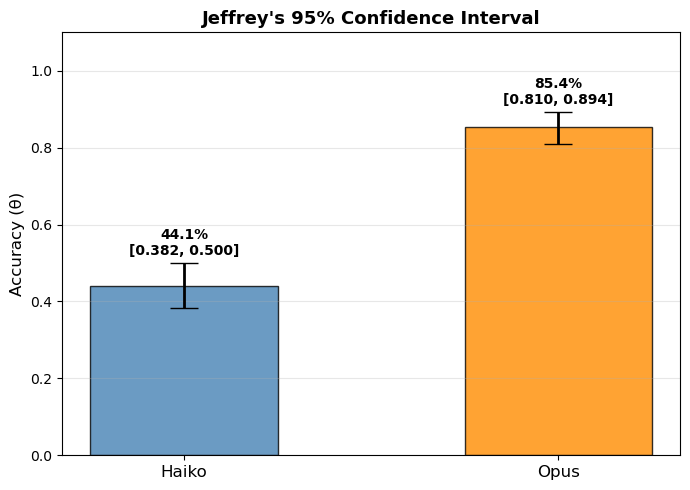

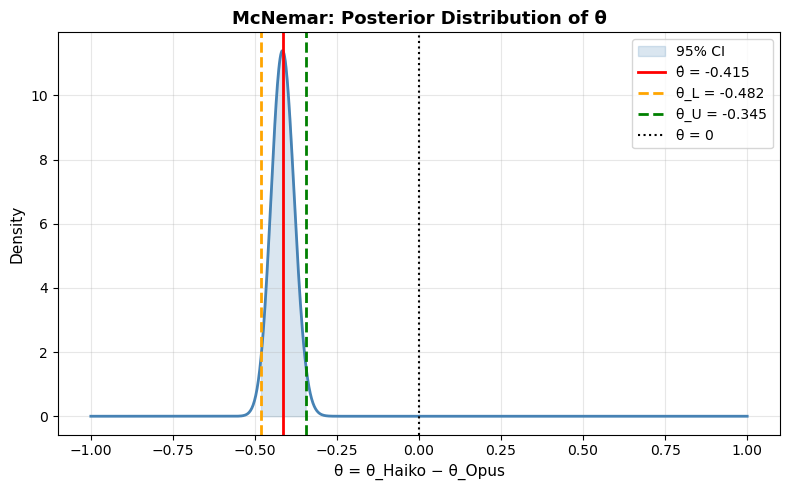

In [12]:
alpha = 0.05

# ══════════════════════════════════════════════════════════════════════════════
# 1) JEFFREY'S INTERVAL  (direkte fra exercise7)
# ══════════════════════════════════════════════════════════════════════════════
def jeffrey_interval(y_true, y_preds, alpha=0.05):
    n         = len(y_true)
    m         = sum(y_true == y_preds)
    a         = m + 0.5
    b         = n - m + 0.5
    CI        = st.beta.interval(1 - alpha, a=a, b=b)
    theta_hat = a / (a + b)
    return theta_hat, CI


alpha = 0.05

theta_haiko, CI_haiko = jeffrey_interval(y_true, yhatA, alpha)
theta_opus,  CI_opus  = jeffrey_interval(y_true, yhatB, alpha)

print("=" * 60)
print("JEFFREY'S INTERVAL (95% CI)")
print("=" * 60)
print(f"\nHaiko:  θ̂ = {theta_haiko:.4f}   CI = [{CI_haiko[0]:.4f}, {CI_haiko[1]:.4f}]")
print(f"Opus:   θ̂ = {theta_opus:.4f}   CI = [{CI_opus[0]:.4f},  {CI_opus[1]:.4f}]")


# ══════════════════════════════════════════════════════════════════════════════
# 2) McNEMAR TEST  (direkte fra exercise7)
# ══════════════════════════════════════════════════════════════════════════════
def mcnemar(y_true, yhatA, yhatB, alpha=0.05):
    nn  = np.zeros((2, 2))
    cA  = yhatA == y_true
    cB  = yhatB == y_true

    nn[0, 0] = sum(cA  &  cB)
    nn[0, 1] = sum(cA  & ~cB)
    nn[1, 0] = sum(~cA &  cB)
    nn[1, 1] = sum(~cA & ~cB)

    n   = len(y_true)
    n12 = nn[0, 1]
    n21 = nn[1, 0]

    E_theta = (n12 - n21) / n

    Q = (n**2 * (n + 1) * (E_theta + 1) * (1 - E_theta)
         / (n * (n12 + n21) - (n12 - n21)**2))

    f  = (E_theta + 1) / 2 * (Q - 1)
    g  = (1 - E_theta)  / 2 * (Q - 1)

    CI = tuple(bound * 2 - 1 for bound in st.beta.interval(1 - alpha, a=f, b=g))

    p  = 2 * st.binom.cdf(min(n12, n21), n=n12 + n21, p=0.5)

    return E_theta, CI, p, nn


E_theta, CI_mc, p_mc, nn = mcnemar(y_true, yhatA, yhatB, alpha)

print("\n" + "=" * 60)
print("McNEMAR TEST")
print("=" * 60)
print(f"\nContingency table:")
print(f"  n11 (Both Correct):     {int(nn[0,0])}")
print(f"  n12 (Haiko ✓, Opus ✗):  {int(nn[0,1])}")
print(f"  n21 (Haiko ✗, Opus ✓):  {int(nn[1,0])}")
print(f"  n22 (Both Wrong):       {int(nn[1,1])}")
print(f"\n  θ̂  (point estimate):    {E_theta:.4f}")
print(f"  95% CI:                 [{CI_mc[0]:.4f}, {CI_mc[1]:.4f}]")
print(f"  p-value:                {p_mc:.4f}")
if p_mc < alpha:
    print(f"\n  Result: SIGNIFICANT (p < {alpha}) ✓")
    print("  Opus performs significantly better than Haiko")
else:
    print(f"\n  Result: NOT SIGNIFICANT (p >= {alpha})")
print("=" * 60)


# ══════════════════════════════════════════════════════════════════════════════
# 3) PLOT 1 – Jeffrey's CI
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(7, 5))

models = ['Haiko', 'Opus']
thetas = [theta_haiko, theta_opus]
cis    = [CI_haiko, CI_opus]
colors = ['steelblue', 'darkorange']

for i, (model, theta, ci, color) in enumerate(zip(models, thetas, cis, colors)):
    ax.bar(i, theta, color=color, alpha=0.8, edgecolor='black', width=0.5)
    ax.errorbar(i, theta,
                yerr=[[theta - ci[0]], [ci[1] - theta]],
                fmt='none', color='black', capsize=10, linewidth=2)
    ax.text(i, ci[1] + 0.02,
            f"{theta:.1%}\n[{ci[0]:.3f}, {ci[1]:.3f}]",
            ha='center', fontsize=10, fontweight='bold')

ax.set_xticks([0, 1])
ax.set_xticklabels(models, fontsize=12)
ax.set_ylim([0, 1.1])
ax.set_ylabel("Accuracy (θ)", fontsize=12)
ax.set_title("Jeffrey's 95% Confidence Interval", fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# 4) PLOT 2 – McNemar posterior distribution
# ══════════════════════════════════════════════════════════════════════════════
n12 = nn[0, 1]
n21 = nn[1, 0]
n   = len(y_true)

E_theta_val = (n12 - n21) / n
Q_val = (n**2 * (n + 1) * (E_theta_val + 1) * (1 - E_theta_val)
         / (n * (n12 + n21) - (n12 - n21)**2))
f_val = (E_theta_val + 1) / 2 * (Q_val - 1)
g_val = (1 - E_theta_val) / 2 * (Q_val - 1)

theta_vals = np.linspace(-1, 1, 1000)
x_vals     = (theta_vals + 1) / 2
y_vals     = st.beta.pdf(x_vals, a=f_val, b=g_val) / 2

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(theta_vals, y_vals, color='steelblue', linewidth=2)
ax.fill_between(theta_vals, y_vals,
                where=(theta_vals >= CI_mc[0]) & (theta_vals <= CI_mc[1]),
                alpha=0.2, color='steelblue', label='95% CI')
ax.axvline(E_theta, color='red',    linestyle='-',  linewidth=2, label=f'θ̂ = {E_theta:.3f}')
ax.axvline(CI_mc[0], color='orange', linestyle='--', linewidth=2, label=f'θ_L = {CI_mc[0]:.3f}')
ax.axvline(CI_mc[1], color='green',  linestyle='--', linewidth=2, label=f'θ_U = {CI_mc[1]:.3f}')
ax.axvline(0,        color='black',  linestyle=':',  linewidth=1.5, label='θ = 0')
ax.set_title("McNemar: Posterior Distribution of θ", fontsize=13, fontweight='bold')
ax.set_xlabel("θ = θ_Haiko − θ_Opus", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()